In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,accuracy_score,recall_score
from imblearn.over_sampling import SMOTE
from sklearn.impute import KNNImputer
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings('ignore')

In [71]:
data=pd.read_csv("processed_data.csv")
data.head()

,Unnamed: 0,Rating,Name,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,returnOnEquity,assetTurnover,fixedAssetTurnover,debtEquityRatio,debtRatio,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,0,AA,Company 44,Rating agency 5,8/16/2005,Energy,0.885237,0.550896,0.143469,36.817520,0.094024,0.188131,1.009959,0.190213,0.143913,0.184689,0.160121,1.541119,3.390181,1.912761,0.631335,0.000000,0.547603,0.049198,10.433176,1.088336,0.190117,1.274560,3.093736,0.153534,0.000000
1,1,BB,Company 135,Rating agency 3,4/28/2009,Basic Industries,2.052828,0.511835,0.260385,0.000000,0.094189,0.132762,0.121490,0.137469,0.130518,0.223959,0.140879,1.388712,3.344361,2.253043,0.686885,0.284569,0.998442,6.286350,12.016261,3.298016,0.133657,0.959817,6.333349,0.032843,13.696790
2,2,CCC,Company 118,Rating agency 3,8/3/2010,Health Care,1.340032,1.090468,0.235971,45.137229,0.121169,0.017074,1.004473,0.069101,0.131112,0.023242,0.045285,1.093698,2.137543,3.829918,0.795181,0.309316,1.001744,0.965080,3.277277,4.811879,0.017046,15.625364,0.973799,0.051749,0.000000
3,4,BBB,Company 309,Rating agency 3,8/31/2010,Energy,1.393784,0.439914,0.027211,21.435616,0.199471,0.201420,0.990008,0.202475,0.083609,0.090809,0.211589,0.418874,0.487557,1.518487,0.606278,0.004395,-0.524239,-2.024697,4.779136,2.550233,0.200256,11.760623,3.911740,0.274350,0.000000
4,5,BBB,Company 56,Rating agency 3,9/30/2010,Miscellaneous,1.187288,0.514920,0.190278,53.102900,0.054140,0.097922,0.508211,0.099159,0.034475,0.089895,0.236613,0.639344,12.741720,1.384159,1.016996,0.386876,0.881115,4.040228,2.519301,2.403030,0.099138,10.459175,4.615069,0.176765,0.077434


In [72]:
data = data.loc[:, ~data.columns.str.startswith('Unnamed')]

In [73]:
data.describe()

,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,returnOnEquity,assetTurnover,fixedAssetTurnover,debtEquityRatio,debtRatio,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
count,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000
mean,1.590187,1.007968,0.366366,40.006941,0.071683,0.088670,0.512874,0.116933,0.047721,0.078686,0.141513,0.756031,4.764868,1.828582,0.644547,0.267488,0.556180,2.266737,4.430384,2.826731,0.093128,9.315136,4.552027,0.151664,5.897127
std,0.716021,0.549017,0.301250,24.953701,0.064880,0.079705,0.332908,0.089670,0.042630,0.075449,0.080050,0.474939,4.257760,0.954650,0.155105,0.152199,0.382677,2.644528,3.086137,0.920038,0.082339,4.586062,3.149286,0.106165,4.700499
min,-0.561963,-0.605174,-0.193124,0.000000,-0.119796,-0.152495,-0.583605,-0.151139,-0.068008,-0.132996,-0.000046,-0.058478,-0.023782,-1.005147,0.240851,-0.182093,-0.580118,-5.343165,-6.793396,-0.098755,-0.153577,-3.642940,-4.861714,-0.168286,-5.585685
25%,1.069441,0.596478,0.130582,22.632438,0.028939,0.035015,0.235474,0.053793,0.021870,0.031084,0.086928,0.384567,1.000859,1.133934,0.537370,0.184324,0.355744,0.497760,2.372007,2.151464,0.036961,6.262339,2.278547,0.075269,2.107218
50%,1.474575,0.946691,0.285869,40.897149,0.067887,0.087172,0.415955,0.112264,0.045777,0.072427,0.128619,0.671353,3.646662,1.643101,0.637585,0.292397,0.653745,2.012036,3.845119,2.663834,0.090792,9.073628,4.067077,0.130533,5.415798
75%,1.981010,1.322421,0.537148,56.083309,0.108716,0.136250,0.852169,0.168095,0.073507,0.128262,0.185108,1.026476,7.481462,2.327579,0.739715,0.360643,0.832111,3.810009,5.761113,3.323539,0.140317,12.024254,6.402498,0.214348,8.609399
max,3.807490,2.706340,1.370136,113.150210,0.253183,0.323086,1.735232,0.374182,0.164524,0.292448,0.418348,2.167586,19.759661,5.021523,1.070781,0.703125,1.655290,9.966066,17.743185,5.960783,0.331459,22.983333,14.785505,0.491876,20.193160


In [74]:
print("shape",data.shape)
print("\nColumn Type")
print(data.dtypes)


shape (2029, 30)

Column Type
Rating                                 object
Name                                   object
Rating Agency Name                     object
Date                                   object
Sector                                 object
currentRatio                          float64
quickRatio                            float64
cashRatio                             float64
daysOfSalesOutstanding                float64
netProfitMargin                       float64
pretaxProfitMargin                    float64
grossProfitMargin                     float64
operatingProfitMargin                 float64
returnOnAssets                        float64
returnOnCapitalEmployed               float64
returnOnEquity                        float64
assetTurnover                         float64
fixedAssetTurnover                    float64
debtEquityRatio                       float64
debtRatio                             float64
effectiveTaxRate                      float64
free

In [75]:
data['Rating'].value_counts()

Rating
BBB    671
BB     490
A      398
B      302
AA      89
CCC     64
AAA      7
CC       5
C        2
D        1
Name: count, dtype: int64

In [ ]:
data = data[data['Rating_en'] != 0]

In [101]:
rating_dict = {
    'AAA': 8,
    'AA': 7,
    'A': 6,
    'BBB': 5,
    'BB': 4,
    'B': 3,
    'CCC': 2,
    'CC': 1,
    'C': 0
}

# Map ratings
data['Rating_en'] = data['Rating'].map(rating_dict)


In [102]:
data['Rating_en'].value_counts()

Rating_en
5.0    671
4.0    490
6.0    398
3.0    302
7.0     89
2.0     64
8.0      7
1.0      5
0.0      2
Name: count, dtype: int64

In [103]:
sector_freq = data['Sector'].value_counts(normalize=True)
data['Sector'] = data['Sector'].map(sector_freq)

In [104]:
# Features and targets
X = data.drop(columns=['Rating', 'Rating Agency Name', 'Name', 'Date','Rating_en'])
y = data['Rating_en']

In [105]:
data['Rating_en'].value_counts()

Rating_en
5.0    671
4.0    490
6.0    398
3.0    302
7.0     89
2.0     64
8.0      7
1.0      5
0.0      2
Name: count, dtype: int64

In [81]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [82]:
models={
    'Logistocs Regression':LogisticRegression(max_iter=1000,random_state=42),
    'Decision Tree':DecisionTreeClassifier(random_state=42),
    'Random_Forest_Classifier':RandomForestClassifier(class_weight='balanced',random_state=42),
    'XGboost':XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    
}


In [93]:
# Class labels mapped from D(1) to AAA(9)
class_labels = [str(i) for i in range(1, 10)]

# Create dictionaries to collect scores
precision_scores = {}
recall_scores = {}

# Train & evaluate
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Get classification report as dictionary
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    print(report)

    # Extract precision & recall only for class labels 1 to 9
    precision = [report[label]['precision'] if label in report else 0 for label in class_labels]
    recall = [report[label]['recall'] if label in report else 0 for label in class_labels]

    precision_scores[name] = precision
    recall_scores[name] = recall

# Convert to DataFrames
precision_df = pd.DataFrame.from_dict(precision_scores, orient='index', columns=class_labels)
recall_df = pd.DataFrame.from_dict(recall_scores, orient='index', columns=class_labels)

{'2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 1.0}, '3': {'precision': 0.3333333333333333, 'recall': 0.125, 'f1-score': 0.18181818181818182, 'support': 8.0}, '4': {'precision': 0.38181818181818183, 'recall': 0.42, 'f1-score': 0.4, 'support': 50.0}, '5': {'precision': 0.39759036144578314, 'recall': 0.34375, 'f1-score': 0.3687150837988827, 'support': 96.0}, '6': {'precision': 0.46078431372549017, 'recall': 0.6266666666666667, 'f1-score': 0.5310734463276836, 'support': 150.0}, '7': {'precision': 0.41818181818181815, 'recall': 0.26436781609195403, 'f1-score': 0.323943661971831, 'support': 87.0}, '8': {'precision': 0.5, 'recall': 0.15384615384615385, 'f1-score': 0.23529411764705882, 'support': 13.0}, '9': {'precision': 0.5, 'recall': 1.0, 'f1-score': 0.6666666666666666, 'support': 1.0}, 'accuracy': 0.43103448275862066, 'macro avg': {'precision': 0.37396350106307585, 'recall': 0.3667038295755968, 'f1-score': 0.3384388947787881, 'support': 406.0}, 'weighted avg': {'preci

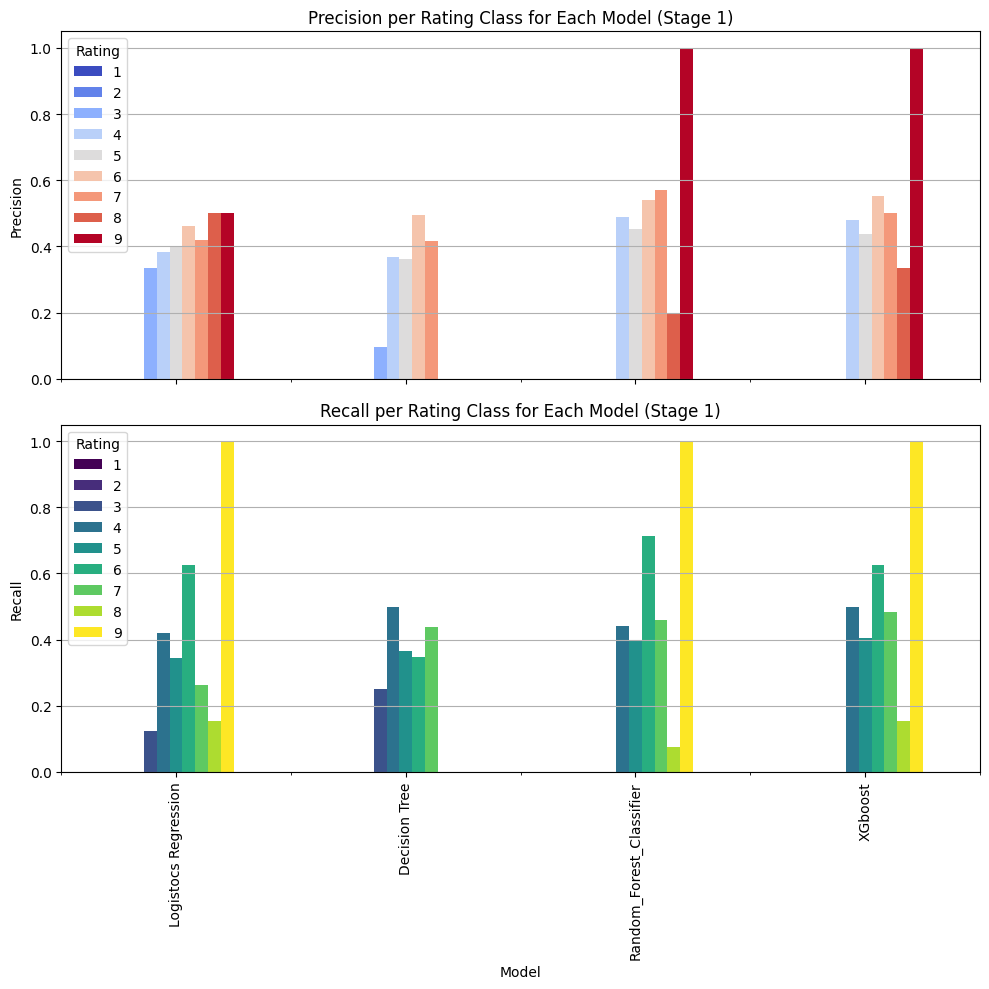

In [86]:
# Plotting
fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

precision_df.plot(kind='bar', ax=axs[0], colormap='coolwarm')
axs[0].set_title('Precision per Rating Class for Each Model (Stage 1)')
axs[0].set_ylabel('Precision')
axs[0].legend(title='Rating')
axs[0].grid(axis='y')

recall_df.plot(kind='bar', ax=axs[1], colormap='viridis')
axs[1].set_title('Recall per Rating Class for Each Model (Stage 1)')
axs[1].set_ylabel('Recall')
axs[1].set_xlabel('Model')
axs[1].legend(title='Rating')
axs[1].grid(axis='y')

plt.tight_layout()
plt.show()

In [100]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.utils import class_weight
import numpy as np


# Calculate class weights
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))


# Initialize the Random Forest Classifier with class weights
rf_model = RandomForestClassifier(class_weight=class_weight_dict, random_state=42)

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_scaled)

# Print classification report
print(classification_report(y_test, y_pred, zero_division=0))


              precision    recall  f1-score   support

           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         8
           4       0.49      0.44      0.46        50
           5       0.45      0.40      0.42        96
           6       0.54      0.71      0.61       150
           7       0.57      0.46      0.51        87
           8       0.20      0.08      0.11        13
           9       1.00      1.00      1.00         1

    accuracy                           0.51       406
   macro avg       0.41      0.39      0.39       406
weighted avg       0.50      0.51      0.50       406



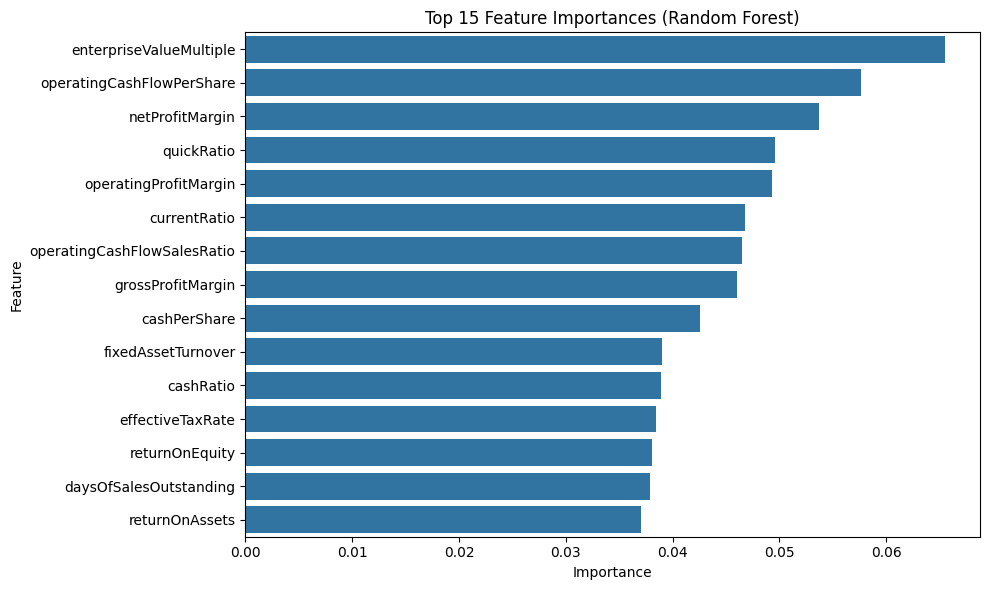

In [85]:
# 1. Access the trained Random Forest model
rf_model = models['Random_Forest_Classifier']  # Already trained above

# 2. Get feature importances
importances = rf_model.feature_importances_

# 3. Match with column names
feature_names = X.columns  # X should be your original feature dataframe (before scaling)
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# 4. Plot top N features
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(15), x='importance', y='feature')
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [92]:
rating_desc_map = {
    'AAA': 'Lowest Risk',
    'AA': 'Low Risk',
    'A': 'Low Risk',
    'BBB': 'Medium Risk',
    'BB': 'High Risk',
    'B': 'High Risk',
    'CCC': 'Highest Risk',
    'CC': 'Highest Risk',
    'C': 'Highest Risk',
}

# Map ratings
data['Rating_en5657'] = data['Rating'].map(rating_desc_map)
data['Rating_en5657'].value_counts()

Rating_en5657
High Risk       792
Medium Risk     671
Low Risk        487
Highest Risk     71
Lowest Risk       7
Name: count, dtype: int64